# Algorithmic Trading Project 
(using Python 3.10.18)

Install all the following packages: 
pandas, numpy, matplotlib, statsmodels, pandas_datareader, datetime, yfinance, 
scikit-learn, PyPortfolioOpt, pandas_ta

Here we have used python 3.10.18 as it is stable and comptible with most of the data science related python
packages.

I changed an import statement in one of the python files manually:
GOTO  >> C:\Users\hp\anaconda3\envs\myenv\Lib\site-packages\pandas_ta\momentum\squeeze_pro.py

REPLACE:
from numpy import NaN as npNaN
WITH:
import numpy as np
npNaN = np.nan

In [48]:
!pip install pandas

In [50]:
!pip install numpy

In [51]:
!pip install matplotlib

In [52]:
!pip install statsmodels

In [53]:
!pip install pandas_datareader

In [385]:
!pip install datetime

In [55]:
!pip install yfinance

In [56]:
!pip install scikit-learn

In [57]:
!pip install PyPortfolioOpt

In [58]:
!pip install pandas_ta

In [12]:
!pip install --upgrade numpy

In [13]:
!where python

C:\Users\hp\anaconda3\envs\myenv\python.exe
C:\Users\hp\anaconda3\python.exe
C:\Program Files\Python312\python.exe
C:\Users\hp\AppData\Local\Microsoft\WindowsApps\python.exe


# 1. Downloading the stocks data  from yfinance and wikipedia

In [407]:
from statsmodels.regression.rolling import RollingOLS
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np
import datetime as ft
import yfinance as yf
import pandas_ta
import warnings
warnings.filterwarnings('ignore')
nifty50 = pd.read_html('https://en.wikipedia.org/wiki/NIFTY_50')[1]  #had 2 dataframes so the second one is [1]
nifty50['Symbol'] = nifty50['Symbol'].str.replace('.', '-')
symbols_list= nifty50['Symbol'].unique().tolist()
symbols_list = [symbol + '.NS' for symbol in symbols_list]  #added .ns in front of each symbol because nse stocks
                                                             #have .ns in yfinance data
#symbols_list = [symbol.removesuffix('.NS') for symbol in symbols_list] #only run it to remove if added .ns twice

end_date = '2025-07-04'
start_date = pd.to_datetime(end_date)-pd.DateOffset(365*3)


df = yf.download(tickers=symbols_list,
               start=start_date,
             end=end_date, auto_adjust=False).stack()

df.index.names = ['date', 'ticker']

df.columns = df.columns.str.lower()
df

# df.to_csv('stock_data.csv')

# import pandas as pd                            #import data 

# df = pd.read_csv('stock_data.csv', index_col=0)  # index_col=0 keeps your index (like dates) intact

# df = pd.read_csv('stock_data.csv')
# df['date'] = pd.to_datetime(df['date'])  # Optional: ensure datetime
# df = df.set_index(['date', 'ticker'])
# df


[*********************100%***********************]  50 of 50 completed


Price                        adj close         close          high  \
date       ticker                                                    
2022-07-05 ADANIENT.NS     2242.322998   2246.449951   2290.699951   
           ADANIPORTS.NS    663.490356    678.750000    694.200012   
           APOLLOHOSP.NS   3780.268066   3817.399902   3874.750000   
           ASIANPAINT.NS   2683.898193   2766.600098   2812.300049   
           AXISBANK.NS      645.803528    648.500000    659.900024   
...                                ...           ...           ...   
2025-07-03 TECHM.NS        1641.900024   1671.900024   1693.000000   
           TITAN.NS        3667.662354   3678.699951   3712.899902   
           TRENT.NS        6191.000000   6191.000000   6258.000000   
           ULTRACEMCO.NS  12319.908203  12398.000000  12575.000000   
           WIPRO.NS         261.898560    267.049988    270.850006   

Price                              low          open     volume  
date       ticker                                                
2022-07-05 ADANIENT.NS     2238.000000   2264.000000  1356776.0  
           ADANIPORTS.NS    676.950012    686.450012  2472875.0  
           APOLLOHOSP.NS   3761.000000   3761.000000   468762.0  
           ASIANPAINT.NS   2760.000000   2785.000000  1073043.0  
           AXISBANK.NS      646.000000    656.099976  5044787.0  
...                                ...           ...        ...  
2025-07-03 TECHM.NS        1670.000000   1684.900024  1713273.0  
           TITAN.NS        3672.199951   3702.000000   528710.0  
           TRENT.NS        6142.500000   6234.000000   750787.0  
           ULTRACEMCO.NS  12376.000000  12436.000000   275755.0  
           WIPRO.NS         266.450012    268.399994  9357962.0  

[36037 rows x 6 columns]

# 2. Calculate features and technical indictors for each stock

1. Garman-Klass Volatility ..
2. RSI
3. Bollinger Bands
4. ATR
5. MACD
6. Volume

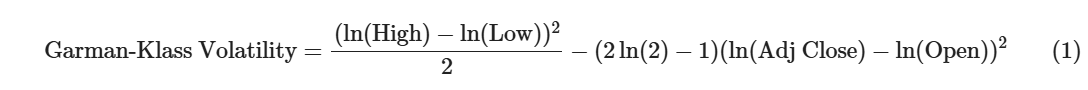

In [408]:
df['garman_klass_vol'] = ((np.log(df['high'])-np.log(df['low']))**2)/2-(2*np.log(2)-1)*((np.log(df['adj close'])-np.log(df['open']))**2)

df['rsi'] = df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.rsi(close=x, length=20))

df['bb_low'] = df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:,0])

df['bb_mid'] = df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:,1])
df['bb_high'] = df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:,2])

def compute_atr(stock_data):
    atr = pandas_ta.atr(high=stock_data['high'],
                       low=stock_data['low'],
                       close=stock_data['close'],
                       length=14)
    return atr.sub(atr.mean()).div(atr.std())
df['atr'] = df.groupby(level=1, group_keys=False).apply(compute_atr)


def compute_macd(close):
    macd = pandas_ta.macd(close=close, length=20).iloc[:,0]
    return macd.sub(macd.mean()).div(macd.std())

df['macd'] = df.groupby(level=1, group_keys=False)['adj close'].apply(compute_macd)



df['rupee_volume'] = (df['adj close']*df['volume'])/1e7

df


Price                        adj close         close          high  \
date       ticker                                                    
2022-07-05 ADANIENT.NS     2242.322998   2246.449951   2290.699951   
           ADANIPORTS.NS    663.490356    678.750000    694.200012   
           APOLLOHOSP.NS   3780.268066   3817.399902   3874.750000   
           ASIANPAINT.NS   2683.898193   2766.600098   2812.300049   
           AXISBANK.NS      645.803528    648.500000    659.900024   
...                                ...           ...           ...   
2025-07-03 TECHM.NS        1641.900024   1671.900024   1693.000000   
           TITAN.NS        3667.662354   3678.699951   3712.899902   
           TRENT.NS        6191.000000   6191.000000   6258.000000   
           ULTRACEMCO.NS  12319.908203  12398.000000  12575.000000   
           WIPRO.NS         261.898560    267.049988    270.850006   

Price                              low          open     volume  \
date       ticker                                                 
2022-07-05 ADANIENT.NS     2238.000000   2264.000000  1356776.0   
           ADANIPORTS.NS    676.950012    686.450012  2472875.0   
           APOLLOHOSP.NS   3761.000000   3761.000000   468762.0   
           ASIANPAINT.NS   2760.000000   2785.000000  1073043.0   
           AXISBANK.NS      646.000000    656.099976  5044787.0   
...                                ...           ...        ...   
2025-07-03 TECHM.NS        1670.000000   1684.900024  1713273.0   
           TITAN.NS        3672.199951   3702.000000   528710.0   
           TRENT.NS        6142.500000   6234.000000   750787.0   
           ULTRACEMCO.NS  12376.000000  12436.000000   275755.0   
           WIPRO.NS         266.450012    268.399994  9357962.0   

Price                     garman_klass_vol        rsi    bb_low    bb_mid  \
date       ticker                                                           
2022-07-05 ADANIENT.NS            0.000235        NaN       NaN       NaN   
           ADANIPORTS.NS         -0.000130        NaN       NaN       NaN   
           APOLLOHOSP.NS          0.000434        NaN       NaN       NaN   
           ASIANPAINT.NS         -0.000352        NaN       NaN       NaN   
           AXISBANK.NS            0.000130        NaN       NaN       NaN   
...                                    ...        ...       ...       ...   
2025-07-03 TECHM.NS              -0.000165  57.916546  7.353253  7.401032   
           TITAN.NS               0.000027  61.977090  8.118331  8.174294   
           TRENT.NS               0.000155  62.132800  8.612689  8.685131   
           ULTRACEMCO.NS          0.000093  66.909571  9.290293  9.356867   
           WIPRO.NS              -0.000098  59.209807  5.512638  5.554202   

Price                      bb_high       atr      macd  rupee_volume  
date       ticker                                                     
2022-07-05 ADANIENT.NS         NaN       NaN       NaN    304.233003  
           ADANIPORTS.NS       NaN       NaN       NaN    164.072872  
           APOLLOHOSP.NS       NaN       NaN       NaN    177.204602  
           ASIANPAINT.NS       NaN       NaN       NaN    287.993817  
           AXISBANK.NS         NaN       NaN       NaN    325.794124  
...                            ...       ...       ...           ...  
2025-07-03 TECHM.NS       7.448811  0.359379  0.954089    281.302298  
           TITAN.NS       8.230257 -0.203126  0.877771    193.912976  
           TRENT.NS       8.757573  0.651024  0.986508    464.812232  
           ULTRACEMCO.NS  9.423440  0.647715  1.434846    339.727629  
           WIPRO.NS       5.595765 -0.175178  0.836658    245.083677  

[36037 rows x 14 columns]

# 3. Aggregate to monthly level and filter top 20 most liquid stocks for each month.

    To reduce training time and experiment with features and strategies, we convert the business-daily data to month-end frequency.

In [409]:
last_cols = [c for c in df.columns.unique(0) if c not in ['rupee_volume', 'volume', 'open',
                                                          'high', 'low', 'close']]


data = (pd.concat([df.unstack('ticker')['rupee_volume'].resample('M').mean().stack('ticker').to_frame('rupee_volume'),
                   df.unstack()[last_cols].resample('M').last().stack('ticker')],
                  axis=1)).dropna()

data

rupee_volume     adj close  garman_klass_vol  \
date       ticker                                                        
2022-08-31 ADANIENT.NS      714.103686   3189.836670          0.000482   
           ADANIPORTS.NS    587.836923    828.919739          0.000207   
           APOLLOHOSP.NS    253.687867   4292.565430          0.000261   
           ASIANPAINT.NS    349.467835   3290.214844          0.000214   
           AXISBANK.NS      539.005583    749.514404          0.000190   
...                                ...           ...               ...   
2025-07-31 TECHM.NS         292.218058   1641.900024         -0.000165   
           TITAN.NS         253.026828   3667.662354          0.000027   
           TRENT.NS         509.647340   6191.000000          0.000155   
           ULTRACEMCO.NS    380.784507  12319.908203          0.000093   
           WIPRO.NS         191.682904    261.898560         -0.000098   

                                rsi    bb_low    bb_mid   bb_high       atr  \
date       ticker                                                             
2022-08-31 ADANIENT.NS    78.554015  7.859004  7.983554  8.108103  0.097540   
           ADANIPORTS.NS  65.941558  6.643173  6.694174  6.745176 -0.549622   
           APOLLOHOSP.NS  58.764206  8.300144  8.354210  8.408276 -0.231612   
           ASIANPAINT.NS  62.459600  8.069285  8.106395  8.143506  1.883324   
           AXISBANK.NS    59.842857  6.575204  6.612751  6.650299 -1.013269   
...                             ...       ...       ...       ...       ...   
2025-07-31 TECHM.NS       57.916546  7.353253  7.401032  7.448811  0.359379   
           TITAN.NS       61.977090  8.118331  8.174294  8.230257 -0.203126   
           TRENT.NS       62.132800  8.612689  8.685131  8.757573  0.651024   
           ULTRACEMCO.NS  66.909571  9.290293  9.356867  9.423440  0.647715   
           WIPRO.NS       59.209807  5.512638  5.554202  5.595765 -0.175178   

                              macd  
date       ticker                   
2022-08-31 ADANIENT.NS    1.609504  
           ADANIPORTS.NS  0.733164  
           APOLLOHOSP.NS  0.275105  
           ASIANPAINT.NS  1.649883  
           AXISBANK.NS    0.492927  
...                            ...  
2025-07-31 TECHM.NS       0.954089  
           TITAN.NS       0.877771  
           TRENT.NS       0.986508  
           ULTRACEMCO.NS  1.434846  
           WIPRO.NS       0.836658  

[1754 rows x 9 columns]

calculate 5-year rolling average of rupee volume for each stocks before filtering

In [410]:
data['rupee_volume'] = (data.loc[:, 'rupee_volume'].unstack('ticker').rolling(5*12, min_periods=12).mean().stack())

data['rupee_vol_rank'] = (data.groupby('date')['rupee_volume'].rank(ascending=False))


data = data[data['rupee_vol_rank']<=20].drop(['rupee_volume', 'rupee_vol_rank'], axis=1) #top 20 acc to volume
data

adj close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                              
2023-07-31 ADANIENT.NS    2489.922119          0.000199  59.948373  7.762600   
           ADANIPORTS.NS   770.776917          0.000460  65.468676  6.546266   
           AXISBANK.NS     952.350525          0.000056  48.901877  6.852581   
           BAJFINANCE.NS   722.911011         -0.000024  50.428631  6.576039   
           BHARTIARTL.NS   873.618408         -0.000106  61.815404  6.744203   
...                               ...               ...        ...       ...   
2025-07-31 RELIANCE.NS    1517.800049          0.000076  65.309215  7.244672   
           SBIN.NS         807.099976          0.000034  54.577098  6.662073   
           TATAMOTORS.NS   690.400024          0.000065  50.336052  6.482921   
           TATASTEEL.NS    165.910004          0.000228  67.250736  5.004171   
           TCS.NS         3389.297852          0.000006  45.711364  8.120724   

                            bb_mid   bb_high       atr      macd  
date       ticker                                                 
2023-07-31 ADANIENT.NS    7.789887  7.817174 -0.800803  0.224384  
           ADANIPORTS.NS  6.588047  6.629828 -1.370211  0.062665  
           AXISBANK.NS    6.871128  6.889675 -0.518875 -0.316255  
           BAJFINANCE.NS  6.616298  6.656558  0.143974  0.130679  
           BHARTIARTL.NS  6.765233  6.786264 -1.053595 -0.096105  
...                            ...       ...       ...       ...  
2025-07-31 RELIANCE.NS    7.290001  7.335329  0.387517  1.316159  
           SBIN.NS        6.690135  6.718197 -0.469127  0.138039  
           TATAMOTORS.NS  6.540952  6.598983 -0.599911 -0.374580  
           TATASTEEL.NS   5.059353  5.114536  0.064392  0.972218  
           TCS.NS         8.139664  8.158604 -0.943585 -0.204269  

[500 rows x 8 columns]

# 4. Calculate Monthly Returns for different time horizons as features.


To capture time series dynamics that reflect, for example, momentum patterns, we compute historical returns using the method .pct_change(lag), that is, returns over various monthly periods as identified by lags.

In [411]:
def calculate_returns(df):

    outlier_cutoff = 0.005

    lags = [1, 2, 3, 6, 9, 12]

    for lag in lags:

        df[f'return_{lag}m'] = (df['adj close']
                              .pct_change(lag)
                              .pipe(lambda x: x.clip(lower=x.quantile(outlier_cutoff),
                                                     upper=x.quantile(1-outlier_cutoff)))
                              .add(1)
                              .pow(1/lag)
                              .sub(1))
    return df
    
    
data = data.groupby(level=1, group_keys=False).apply(calculate_returns).dropna()

data

adj close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                              
2024-07-31 ADANIENT.NS    3167.780273          0.000167  53.867996  7.992681   
           ADANIPORTS.NS  1562.299194          0.000191  63.742150  7.273435   
           AXISBANK.NS    1165.104248          0.000088  38.081545  7.051533   
           BAJFINANCE.NS   677.440918          0.000018  45.107406  6.489845   
           BHARTIARTL.NS  1470.986694          0.000208  59.437774  7.236189   
...                               ...               ...        ...       ...   
2025-07-31 RELIANCE.NS    1517.800049          0.000076  65.309215  7.244672   
           SBIN.NS         807.099976          0.000034  54.577098  6.662073   
           TATAMOTORS.NS   690.400024          0.000065  50.336052  6.482921   
           TATASTEEL.NS    165.910004          0.000228  67.250736  5.004171   
           TCS.NS         3389.297852          0.000006  45.711364  8.120724   

                            bb_mid   bb_high       atr      macd  return_1m  \
date       ticker                                                             
2024-07-31 ADANIENT.NS    8.033157  8.073634 -0.495738 -0.177913  -0.002439   
           ADANIPORTS.NS  7.310126  7.346817  0.392601  0.752144   0.062107   
           AXISBANK.NS    7.137170  7.222807  1.768998 -1.402791  -0.077212   
           BAJFINANCE.NS  6.539849  6.589854 -0.654589 -0.846597  -0.043370   
           BHARTIARTL.NS  7.269510  7.302831  0.925367  0.453892   0.032894   
...                            ...       ...       ...       ...        ...   
2025-07-31 RELIANCE.NS    7.290001  7.335329  0.387517  1.316159   0.011462   
           SBIN.NS        6.690135  6.718197 -0.469127  0.138039  -0.016152   
           TATAMOTORS.NS  6.540952  6.598983 -0.599911 -0.374580   0.003488   
           TATASTEEL.NS   5.059353  5.114536  0.064392  0.972218   0.038495   
           TCS.NS         8.139664  8.158604 -0.943585 -0.204269  -0.017678   

                          return_2m  return_3m  return_6m  return_9m  \
date       ticker                                                      
2024-07-31 ADANIENT.NS    -0.035920   0.012499   0.001515   0.036583   
           ADANIPORTS.NS   0.047314   0.059700   0.045438   0.079729   
           AXISBANK.NS     0.002084   0.000314   0.014924   0.019380   
           BAJFINANCE.NS   0.010650  -0.003984  -0.000530  -0.010034   
           BHARTIARTL.NS   0.042373   0.040965   0.041195   0.055872   
...                             ...        ...        ...        ...   
2025-07-31 RELIANCE.NS     0.033536   0.026076   0.030817   0.014610   
           SBIN.NS        -0.003206   0.014438   0.010585   0.000420   
           TATAMOTORS.NS  -0.016229   0.026254  -0.004654  -0.019852   
           TATASTEEL.NS    0.026839   0.066194   0.039431   0.014945   
           TCS.NS         -0.004684  -0.002193  -0.029740  -0.015778   

                          return_12m  
date       ticker                     
2024-07-31 ADANIENT.NS      0.020268  
           ADANIPORTS.NS    0.060255  
           AXISBANK.NS      0.016881  
           BAJFINANCE.NS   -0.005399  
           BHARTIARTL.NS    0.044377  
...                              ...  
2025-07-31 RELIANCE.NS      0.000965  
           SBIN.NS         -0.004815  
           TATAMOTORS.NS   -0.041095  
           TATASTEEL.NS     0.002215  
           TCS.NS          -0.019373  

[247 rows x 14 columns]

# 5. Download Fama French Factors and Calculate Rolling Factor Betas

In [412]:
factor_data = web.DataReader('F-F_Research_Data_5_Factors_2x3',
                               'famafrench',
                               start='2010')[0].drop('RF', axis=1)

factor_data.index = factor_data.index.to_timestamp()

factor_data = factor_data.resample('M').last().div(100)

factor_data.index.name = 'date'

factor_data = factor_data.join(data['return_1m']).sort_index()

factor_data

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                          
2024-07-31 ADANIENT.NS    0.0122  0.0834  0.0562  0.0027  0.0028  -0.002439
           ADANIPORTS.NS  0.0122  0.0834  0.0562  0.0027  0.0028   0.062107
           AXISBANK.NS    0.0122  0.0834  0.0562  0.0027  0.0028  -0.077212
           BAJFINANCE.NS  0.0122  0.0834  0.0562  0.0027  0.0028  -0.043370
           BHARTIARTL.NS  0.0122  0.0834  0.0562  0.0027  0.0028   0.032894
...                          ...     ...     ...     ...     ...        ...
2025-06-30 RELIANCE.NS    0.0486 -0.0002 -0.0160 -0.0319  0.0145   0.056091
           SBIN.NS        0.0486 -0.0002 -0.0160 -0.0319  0.0145   0.009910
           TATAMOTORS.NS  0.0486 -0.0002 -0.0160 -0.0319  0.0145  -0.035559
           TATASTEEL.NS   0.0486 -0.0002 -0.0160 -0.0319  0.0145   0.015313
           TCS.NS         0.0486 -0.0002 -0.0160 -0.0319  0.0145   0.008481

[228 rows x 6 columns]

# Filter out stocks with less than 10 months of data

In [413]:
observations = factor_data.groupby(level=1).size()

valid_stocks = observations[observations >=10]

factor_data = factor_data[factor_data.index.get_level_values('ticker').isin(valid_stocks.index)]

factor_data

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                          
2024-07-31 ADANIENT.NS    0.0122  0.0834  0.0562  0.0027  0.0028  -0.002439
           ADANIPORTS.NS  0.0122  0.0834  0.0562  0.0027  0.0028   0.062107
           AXISBANK.NS    0.0122  0.0834  0.0562  0.0027  0.0028  -0.077212
           BAJFINANCE.NS  0.0122  0.0834  0.0562  0.0027  0.0028  -0.043370
           BHARTIARTL.NS  0.0122  0.0834  0.0562  0.0027  0.0028   0.032894
...                          ...     ...     ...     ...     ...        ...
2025-06-30 RELIANCE.NS    0.0486 -0.0002 -0.0160 -0.0319  0.0145   0.056091
           SBIN.NS        0.0486 -0.0002 -0.0160 -0.0319  0.0145   0.009910
           TATAMOTORS.NS  0.0486 -0.0002 -0.0160 -0.0319  0.0145  -0.035559
           TATASTEEL.NS   0.0486 -0.0002 -0.0160 -0.0319  0.0145   0.015313
           TCS.NS         0.0486 -0.0002 -0.0160 -0.0319  0.0145   0.008481

[228 rows x 6 columns]

In [414]:
print("Remaining valid stocks:", len(valid_stocks))


Remaining valid stocks: 19


In [415]:
print("Rows in factor_data after filtering:", len(factor_data))


Rows in factor_data after filtering: 228


# Calculate Rolling factor betas

In [416]:
betas = (factor_data.groupby(level=1,
                            group_keys=False)
         .apply(lambda x: RollingOLS(endog=x['return_1m'], 
                                     exog=sm.add_constant(x.drop('return_1m', axis=1)),
                                     window=min(24, x.shape[0]),
                                     min_nobs=len(x.columns)+1)
         .fit(params_only=True)
         .params
         .drop('const', axis=1)))

betas 

Mkt-RF       SMB       HML       RMW       CMA
date       ticker                                                         
2024-07-31 ADANIENT.NS         NaN       NaN       NaN       NaN       NaN
           ADANIPORTS.NS       NaN       NaN       NaN       NaN       NaN
           AXISBANK.NS         NaN       NaN       NaN       NaN       NaN
           BAJFINANCE.NS       NaN       NaN       NaN       NaN       NaN
           BHARTIARTL.NS       NaN       NaN       NaN       NaN       NaN
...                            ...       ...       ...       ...       ...
2025-06-30 RELIANCE.NS   -0.103421 -0.220136 -0.270560 -0.837079 -0.662619
           SBIN.NS       -0.954357  1.400311 -0.881067 -0.417593  0.503050
           TATAMOTORS.NS  0.194800  1.753570 -0.167556  2.746636 -0.290939
           TATASTEEL.NS   0.823765 -0.110622 -0.156473  2.721777  0.273572
           TCS.NS         0.488950  1.324355  0.041025  1.338356 -1.180284

[228 rows x 5 columns]

# Join the rolling factors data to the main features dataframe.

In [417]:
factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
data = (data.join(betas.groupby('ticker').shift()))
for col in factors:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Step 1: Group-based fill
data[factors] = data.groupby('ticker')[factors].transform(lambda x: x.fillna(x.mean()))

# Step 2: Global fill (in case groups were all-NaN)
data[factors] = data[factors].fillna(data[factors].mean())

# Step 3: Final fallback (optional)
# Fill remaining NaNs with 0 or drop those rows
data[factors] = data[factors].fillna(0)
# OR
# data = data.dropna(subset=factors)

data = data.drop('adj close', axis=1)

data = data.dropna()

data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 247 entries, (Timestamp('2024-07-31 00:00:00'), 'ADANIENT.NS') to (Timestamp('2025-07-31 00:00:00'), 'TCS.NS')
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   garman_klass_vol  247 non-null    float64
 1   rsi               247 non-null    float64
 2   bb_low            247 non-null    float64
 3   bb_mid            247 non-null    float64
 4   bb_high           247 non-null    float64
 5   atr               247 non-null    float64
 6   macd              247 non-null    float64
 7   return_1m         247 non-null    float64
 8   return_2m         247 non-null    float64
 9   return_3m         247 non-null    float64
 10  return_6m         247 non-null    float64
 11  return_9m         247 non-null    float64
 12  return_12m        247 non-null    float64
 13  Mkt-RF            247 non-null    float64
 14  SMB               247 non-null    float64
 15  HM

# At this point we have to decide on what ML model and approach to use for predictions etc.

# 6. For each month fit a K-Means Clustering Algorithm to group similar assets based on their features.

# K-Means Clustering


You may want to initialize predefined centroids for each cluster based on your research.

For visualization purpose of this tutorial we will initially rely on the ‘k-means++’ initialization.

Then we will pre-define our centroids for each cluster.

In [418]:
from sklearn.cluster import KMeans

#data = data.drop('cluster', axis=1)

def get_clusters(df):
    df['cluster'] = KMeans(n_clusters=4,
                           random_state=0,
                           init='random').fit(df).labels_
    return df

data = data.dropna().groupby('date', group_keys=False).apply(get_clusters)

data

garman_klass_vol        rsi    bb_low    bb_mid  \
date       ticker                                                           
2024-07-31 ADANIENT.NS            0.000167  53.867996  7.992681  8.033157   
           ADANIPORTS.NS          0.000191  63.742150  7.273435  7.310126   
           AXISBANK.NS            0.000088  38.081545  7.051533  7.137170   
           BAJFINANCE.NS          0.000018  45.107406  6.489845  6.539849   
           BHARTIARTL.NS          0.000208  59.437774  7.236189  7.269510   
...                                    ...        ...       ...       ...   
2025-07-31 RELIANCE.NS            0.000076  65.309215  7.244672  7.290001   
           SBIN.NS                0.000034  54.577098  6.662073  6.690135   
           TATAMOTORS.NS          0.000065  50.336052  6.482921  6.540952   
           TATASTEEL.NS           0.000228  67.250736  5.004171  5.059353   
           TCS.NS                 0.000006  45.711364  8.120724  8.139664   

                           bb_high       atr      macd  return_1m  return_2m  \
date       ticker                                                              
2024-07-31 ADANIENT.NS    8.073634 -0.495738 -0.177913  -0.002439  -0.035920   
           ADANIPORTS.NS  7.346817  0.392601  0.752144   0.062107   0.047314   
           AXISBANK.NS    7.222807  1.768998 -1.402791  -0.077212   0.002084   
           BAJFINANCE.NS  6.589854 -0.654589 -0.846597  -0.043370   0.010650   
           BHARTIARTL.NS  7.302831  0.925367  0.453892   0.032894   0.042373   
...                            ...       ...       ...        ...        ...   
2025-07-31 RELIANCE.NS    7.335329  0.387517  1.316159   0.011462   0.033536   
           SBIN.NS        6.718197 -0.469127  0.138039  -0.016152  -0.003206   
           TATAMOTORS.NS  6.598983 -0.599911 -0.374580   0.003488  -0.016229   
           TATASTEEL.NS   5.114536  0.064392  0.972218   0.038495   0.026839   
           TCS.NS         8.158604 -0.943585 -0.204269  -0.017678  -0.004684   

                          return_3m  return_6m  return_9m  return_12m  Mkt-RF  \
date       ticker                                                               
2024-07-31 ADANIENT.NS     0.012499   0.001515   0.036583    0.020268     0.0   
           ADANIPORTS.NS   0.059700   0.045438   0.079729    0.060255     0.0   
           AXISBANK.NS     0.000314   0.014924   0.019380    0.016881     0.0   
           BAJFINANCE.NS  -0.003984  -0.000530  -0.010034   -0.005399     0.0   
           BHARTIARTL.NS   0.040965   0.041195   0.055872    0.044377     0.0   
...                             ...        ...        ...         ...     ...   
2025-07-31 RELIANCE.NS     0.026076   0.030817   0.014610    0.000965     0.0   
           SBIN.NS         0.014438   0.010585   0.000420   -0.004815     0.0   
           TATAMOTORS.NS   0.026254  -0.004654  -0.019852   -0.041095     0.0   
           TATASTEEL.NS    0.066194   0.039431   0.014945    0.002215     0.0   
           TCS.NS         -0.002193  -0.029740  -0.015778   -0.019373     0.0   

                          SMB  HML  RMW  CMA  cluster  
date       ticker                                      
2024-07-31 ADANIENT.NS    0.0  0.0  0.0  0.0        3  
           ADANIPORTS.NS  0.0  0.0  0.0  0.0        2  
           AXISBANK.NS    0.0  0.0  0.0  0.0        0  
           BAJFINANCE.NS  0.0  0.0  0.0  0.0        0  
           BHARTIARTL.NS  0.0  0.0  0.0  0.0        2  
...                       ...  ...  ...  ...      ...  
2025-07-31 RELIANCE.NS    0.0  0.0  0.0  0.0        0  
           SBIN.NS        0.0  0.0  0.0  0.0        1  
           TATAMOTORS.NS  0.0  0.0  0.0  0.0        2  
           TATASTEEL.NS   0.0  0.0  0.0  0.0        0  
           TCS.NS         0.0  0.0  0.0  0.0        3  

[247 rows x 19 columns]

# Plot Description

In [419]:
def plot_clusters(data):

    cluster_0 = data[data['cluster']==0]
    cluster_1 = data[data['cluster']==1]
    cluster_2 = data[data['cluster']==2]
    cluster_3 = data[data['cluster']==3]

    plt.scatter(cluster_0.iloc[:,0] , cluster_0.iloc[:,6] , color = 'red', label='cluster 0')
    plt.scatter(cluster_1.iloc[:,0] , cluster_1.iloc[:,6] , color = 'green', label='cluster 1')
    plt.scatter(cluster_2.iloc[:,0] , cluster_2.iloc[:,6] , color = 'blue', label='cluster 2')
    plt.scatter(cluster_3.iloc[:,0] , cluster_3.iloc[:,6] , color = 'black', label='cluster 3')
    
    plt.legend()
    plt.show()
    return

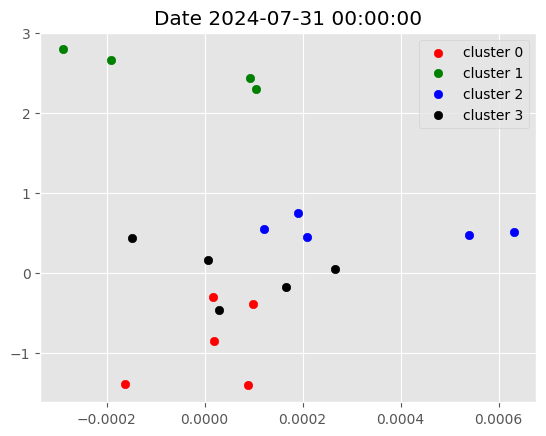

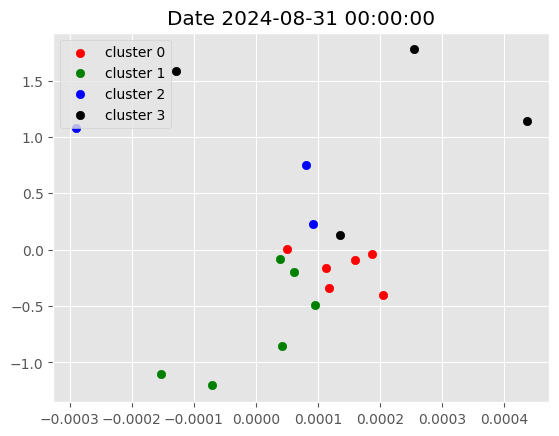

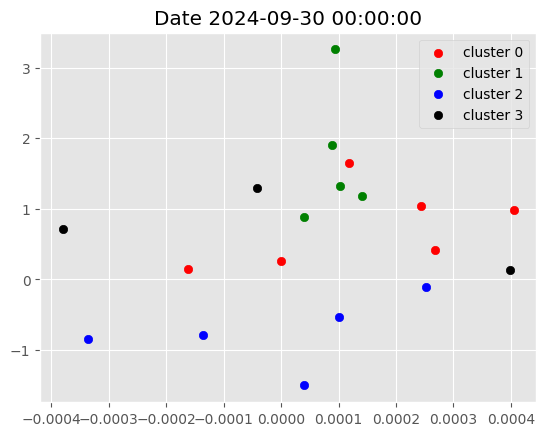

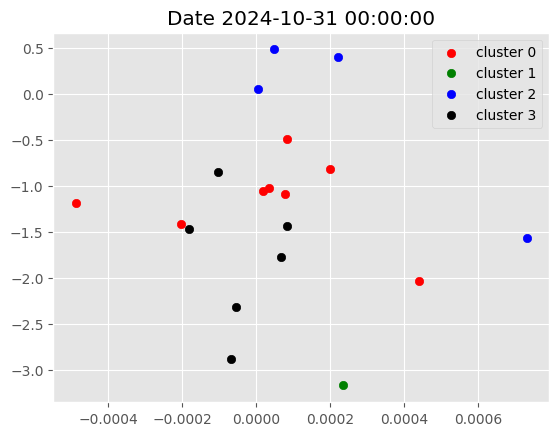

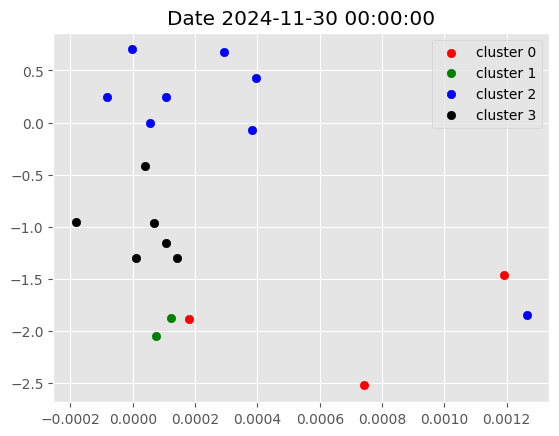

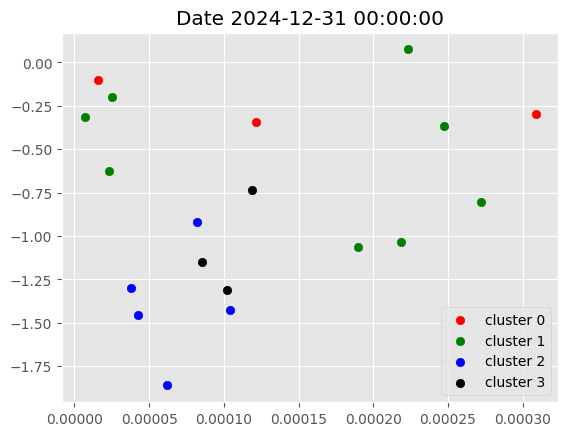

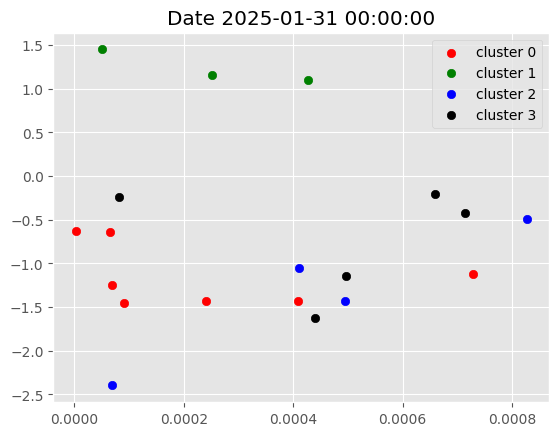

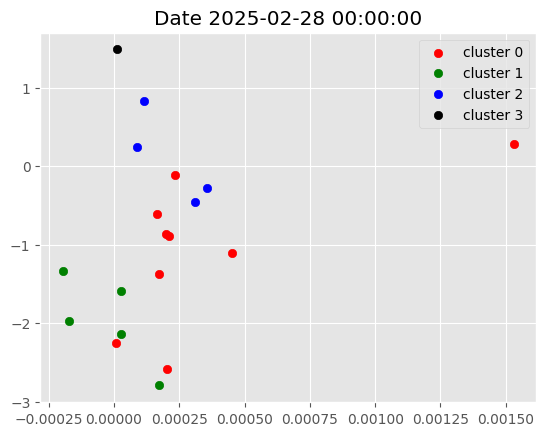

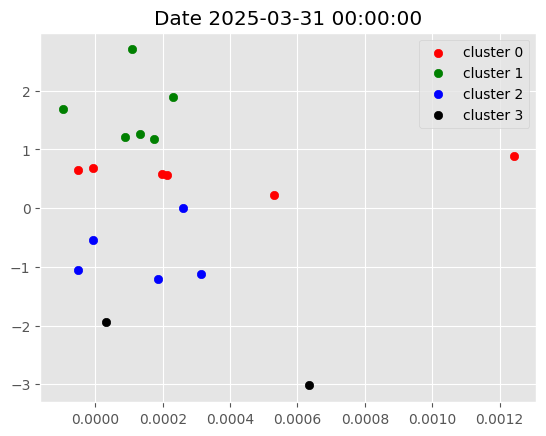

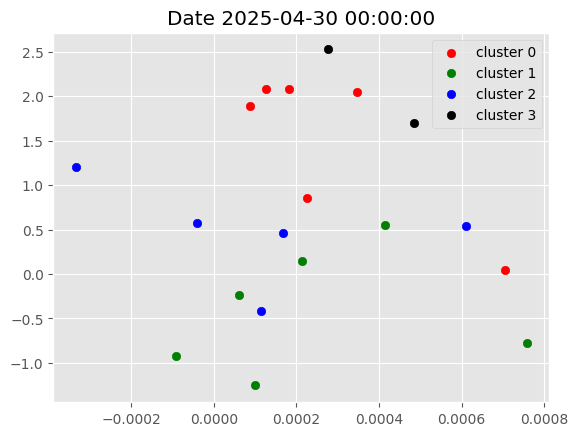

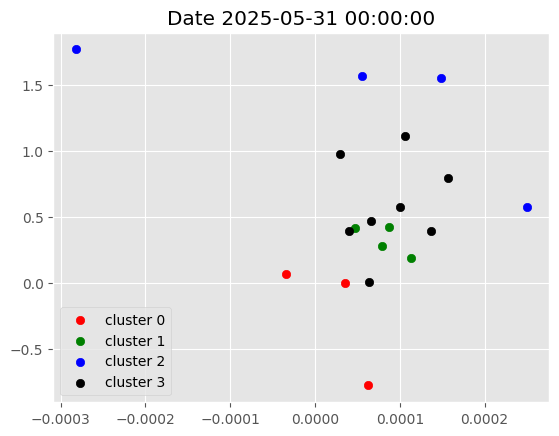

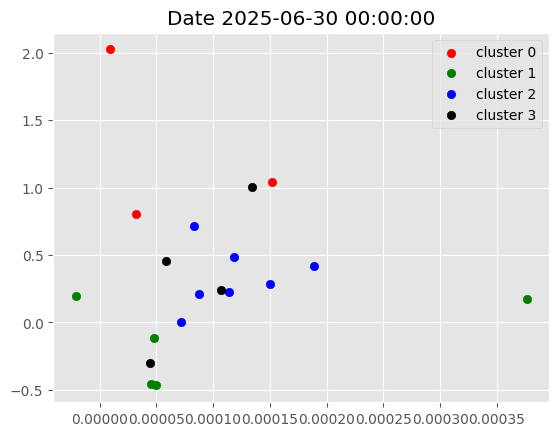

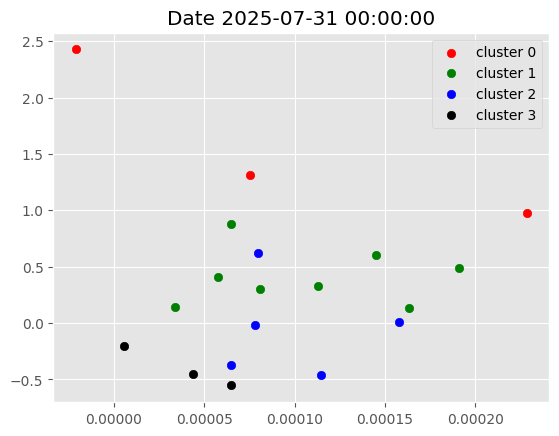

In [420]:
plt.style.use('ggplot')

for i in data.index.get_level_values('date').unique().tolist():
    
    g = data.xs(i, level=0)
    
    plt.title(f'Date {i}')
    
    plot_clusters(g)

# Apply pre defined centroids

In [421]:
target_rsi_values = [30, 45, 55, 70]

initial_centroids = np.zeros((len(target_rsi_values), 18))

initial_centroids[:, 6] = target_rsi_values

initial_centroids

array([[ 0.,  0.,  0.,  0.,  0.,  0., 30.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 45.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 55.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 70.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.]])

# 7. For each month select assets based on the cluster and form a portfolio based on Efficient Frontier max sharpe ratio optimization

First we will filter only stocks corresponding to the cluster we choose based on our hypothesis.

Momentum is persistent and my idea would be that stocks clustered around RSI 70 centroid should continue to outperform in the following month - thus I would select stocks corresponding to cluster 3.

In [423]:
filtered_df = data[data['cluster']==3].copy()

filtered_df = filtered_df.reset_index(level=1)

filtered_df.index = filtered_df.index+pd.DateOffset(1)

filtered_df = filtered_df.reset_index().set_index(['date', 'ticker'])

dates = filtered_df.index.get_level_values('date').unique().tolist()

fixed_dates = {}

for d in dates:
    
    fixed_dates[d.strftime('%Y-%m-%d')] = filtered_df.xs(d, level=0).index.tolist()
    
fixed_dates

{'2024-08-01': ['ADANIENT.NS',
  'HDFCBANK.NS',
  'ICICIBANK.NS',
  'KOTAKBANK.NS',
  'SBIN.NS'],
 '2024-09-01': ['BAJFINANCE.NS', 'BHARTIARTL.NS', 'INFY.NS', 'TCS.NS'],
 '2024-10-01': ['ADANIENT.NS', 'HDFCBANK.NS', 'ITC.NS'],
 '2024-11-01': ['INFY.NS',
  'KOTAKBANK.NS',
  'MARUTI.NS',
  'RELIANCE.NS',
  'TATAMOTORS.NS',
  'TCS.NS'],
 '2024-12-01': ['AXISBANK.NS',
  'BAJFINANCE.NS',
  'ITC.NS',
  'KOTAKBANK.NS',
  'RELIANCE.NS',
  'TATASTEEL.NS'],
 '2025-01-01': ['MARUTI.NS', 'SBIN.NS', 'TCS.NS'],
 '2025-02-01': ['BHARTIARTL.NS',
  'INDUSINDBK.NS',
  'LT.NS',
  'M&M.NS',
  'RELIANCE.NS'],
 '2025-03-01': ['BAJFINANCE.NS'],
 '2025-04-01': ['INDUSINDBK.NS', 'INFY.NS'],
 '2025-05-01': ['ICICIBANK.NS', 'RELIANCE.NS'],
 '2025-06-01': ['ADANIENT.NS',
  'AXISBANK.NS',
  'BAJFINANCE.NS',
  'BHARTIARTL.NS',
  'HDFCBANK.NS',
  'ICICIBANK.NS',
  'RELIANCE.NS',
  'TATAMOTORS.NS'],
 '2025-07-01': ['BAJFINANCE.NS', 'ICICIBANK.NS', 'INFY.NS', 'KOTAKBANK.NS'],
 '2025-08-01': ['AXISBANK.NS', 'ITC.NS', '

# Define portfolio optimization function

We will define a function which optimizes portfolio weights using PyPortfolioOpt package and EfficientFrontier optimizer to maximize the sharpe ratio.

To optimize the weights of a given portfolio we would need to supply last 1 year prices to the function.

Apply signle stock weight bounds constraint for diversification (minimum half of equaly weight and maximum 10% of portfolio).

In [424]:
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

def optimize_weights(prices, lower_bound=0):
    
    returns = expected_returns.mean_historical_return(prices=prices,
                                                      frequency=252)
    
    cov = risk_models.sample_cov(prices=prices,
                                 frequency=252)
    
    ef = EfficientFrontier(expected_returns=returns,
                           cov_matrix=cov,
                           weight_bounds=(lower_bound, .1),
                           solver='SCS')
    
    weights = ef.max_sharpe()
    
    return ef.clean_weights()

# Download Fresh Daily Prices Data only for short listed stocks.

In [425]:
stocks = data.index.get_level_values('ticker').unique().tolist()

new_df = yf.download(tickers=stocks,
                     start=data.index.get_level_values('date').unique()[0]-pd.DateOffset(months=12),
                     end=data.index.get_level_values('date').unique()[-1])

new_df



[*********************100%***********************]  19 of 19 completed


Price             Close                                           \
Ticker      ADANIENT.NS ADANIPORTS.NS  AXISBANK.NS BAJFINANCE.NS   
Date                                                               
2023-07-31  2489.922119    770.776917   952.350525    722.911011   
2023-08-01  2478.832275    758.390564   958.340759    719.880798   
2023-08-02  2471.289307    754.526062   943.714539    713.320374   
2023-08-03  2530.285645    766.317810   934.030334    703.903198   
2023-08-04  2539.476807    768.200562   950.703186    707.898804   
...                 ...           ...          ...           ...   
2025-07-24  2608.399902   1411.599976  1095.099976    958.950012   
2025-07-25  2550.100098   1396.300049  1086.099976    913.750000   
2025-07-28  2522.300049   1376.000000  1073.599976    880.500000   
2025-07-29  2547.899902   1395.900024  1064.199951    886.549988   
2025-07-30  2532.899902   1394.000000  1073.300049    884.849976   

Price                                                                          \
Ticker     BHARTIARTL.NS  HDFCBANK.NS ICICIBANK.NS INDUSINDBK.NS      INFY.NS   
Date                                                                            
2023-07-31    873.618408  1611.230591   981.698547   1402.183228  1286.664795   
2023-08-01    875.336365  1622.013184   978.010864   1379.287476  1295.680908   
2023-08-02    862.034302  1600.789673   970.537292   1366.083984  1287.756104   
2023-08-03    855.751404  1589.226562   948.952271   1349.517944  1294.826904   
2023-08-04    873.373047  1612.206421   954.360840   1394.122681  1308.161377   
...                  ...          ...          ...           ...          ...   
2025-07-24   1936.099976  2014.199951  1483.400024    847.900024  1552.500000   
2025-07-25   1937.900024  2004.599976  1477.099976    823.700012  1515.699951   
2025-07-28   1890.300049  2008.500000  1488.400024    802.049988  1516.000000   
2025-07-29   1918.300049  2021.599976  1486.199951    808.200012  1513.699951   
2025-07-30   1932.599976  2025.800049  1482.400024    801.900024  1519.000000   

Price                   ...    Volume                                 \
Ticker          ITC.NS  ...    ITC.NS KOTAKBANK.NS    LT.NS   M&M.NS   
Date                    ...                                            
2023-07-31  435.921356  ...   8194797      4025207  1284981  2460789   
2023-08-01  435.078857  ...   6438221      4467942  1298745  4184243   
2023-08-02  430.679443  ...  10318220      4180451  1479486  3188395   
2023-08-03  426.888367  ...  10617897      7015292  1612618  2222395   
2023-08-04  425.858734  ...   6834401      5443532  1101278  8066091   
...                ...  ...       ...          ...      ...      ...   
2025-07-24  409.950012  ...   9005157      2058400  1083671  1469406   
2025-07-25  409.399994  ...   5824089      1745475  1338744  1475856   
2025-07-28  409.899994  ...   8123337     13824699  2256080  1939520   
2025-07-29  408.450012  ...   6811772      5043934  1241060  1824673   
2025-07-30  407.600006  ...  10915863      3589991  8760659  2199654   

Price                                                                           
Ticker     MARUTI.NS RELIANCE.NS   SBIN.NS TATAMOTORS.NS TATASTEEL.NS   TCS.NS  
Date                                                                            
2023-07-31    600060     8551174   8605483       7502361     52330311  2743678  
2023-08-01   1394528     9536632  13493453       8924219     27863562  1956167  
2023-08-02    672815    12748214  14977497      15762687     54951586  1914899  
2023-08-03    614897    10168350  27774877      11458920     34624188  2026351  
2023-08-04    540470    22885610  52725616      11806739     22303966  2248493  
...              ...         ...       ...           ...          ...      ...  
2025-07-24    157163    14740507  10118309      15197664     14377270  2934778  
2025-07-25    260700    11854722   6734439       7271718     12443495  2568917  
2025-07-28  

Calculate daily returns for each stock which could land up in our portfolio.

Then loop over each month start, select the stocks for the month and calculate their weights for the next month.

If the maximum sharpe ratio optimization fails for a given month, apply equally-weighted weights.

Calculated each day portfolio return.

In [426]:
print(new_df.columns.names)
print(new_df.columns.levels)
print(new_df.columns[:5])


['Price', 'Ticker']
[['Close', 'High', 'Low', 'Open', 'Volume'], ['ADANIENT.NS', 'ADANIPORTS.NS', 'AXISBANK.NS', 'BAJFINANCE.NS', 'BHARTIARTL.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'INDUSINDBK.NS', 'INFY.NS', 'ITC.NS', 'KOTAKBANK.NS', 'LT.NS', 'M&M.NS', 'MARUTI.NS', 'RELIANCE.NS', 'SBIN.NS', 'TATAMOTORS.NS', 'TATASTEEL.NS', 'TCS.NS']]
MultiIndex([('Close',   'ADANIENT.NS'),
            ('Close', 'ADANIPORTS.NS'),
            ('Close',   'AXISBANK.NS'),
            ('Close', 'BAJFINANCE.NS'),
            ('Close', 'BHARTIARTL.NS')],
           names=['Price', 'Ticker'])


In [427]:
returns_dataframe = np.log(new_df['Close']).diff()
portfolio_df = pd.DataFrame()

for start_date in fixed_dates.keys():
    try:
        end_date = (pd.to_datetime(start_date) + pd.offsets.MonthEnd(0)).strftime('%Y-%m-%d')
        cols = fixed_dates[start_date]

        optimization_start_date = (pd.to_datetime(start_date) - pd.DateOffset(months=12)).strftime('%Y-%m-%d')
        optimization_end_date = (pd.to_datetime(start_date) - pd.DateOffset(days=1)).strftime('%Y-%m-%d')

        optimization_df = new_df[optimization_start_date:optimization_end_date]['Close'][cols]

        success = False
        try:
            weights = optimize_weights(prices=optimization_df,
                                       lower_bound=round(1 / (len(optimization_df.columns) * 2), 3))
            weights = pd.DataFrame(weights, index=pd.Series(0))
            success = True
        except:
            print(f'Max Sharpe Optimization failed for {start_date}, Continuing with Equal-Weights')

        if not success:
            weights = pd.DataFrame([1 / len(optimization_df.columns) for _ in range(len(optimization_df.columns))],
                                   index=optimization_df.columns.tolist(),
                                   columns=pd.Series(0)).T

        # Get returns for evaluation period
        temp_returns = returns_dataframe[start_date:end_date][cols]

        # Reshape returns to long format
        temp_df = temp_returns.stack().reset_index()
        temp_df.columns = ['date', 'ticker', 'return']

        # Reshape weights to long format
        weights_stacked = weights.stack().reset_index()
        weights_stacked.columns = ['row', 'ticker', 'weight']  # row will be 0

        # Merge weights with returns on ticker
        temp_df = temp_df.merge(weights_stacked[['ticker', 'weight']], on='ticker', how='left')

        # Compute weighted return
        temp_df['weighted_return'] = temp_df['return'] * temp_df['weight']

        # Group by date to get strategy return
        strategy_return = temp_df.groupby('date')['weighted_return'].sum().to_frame('Strategy Return')

        # Append to final portfolio
        portfolio_df = pd.concat([portfolio_df, strategy_return], axis=0)

    except Exception as e:
        print(f"Error on {start_date}: {e}")

# Clean up duplicates and sort
portfolio_df = portfolio_df[~portfolio_df.index.duplicated(keep='first')]
portfolio_df = portfolio_df.sort_index()

# View the result
portfolio_df


Max Sharpe Optimization failed for 2024-08-01, Continuing with Equal-Weights
Max Sharpe Optimization failed for 2024-09-01, Continuing with Equal-Weights
Max Sharpe Optimization failed for 2024-10-01, Continuing with Equal-Weights
Max Sharpe Optimization failed for 2024-11-01, Continuing with Equal-Weights
Max Sharpe Optimization failed for 2024-12-01, Continuing with Equal-Weights
Max Sharpe Optimization failed for 2025-01-01, Continuing with Equal-Weights
Max Sharpe Optimization failed for 2025-02-01, Continuing with Equal-Weights
Max Sharpe Optimization failed for 2025-03-01, Continuing with Equal-Weights
Max Sharpe Optimization failed for 2025-04-01, Continuing with Equal-Weights
Max Sharpe Optimization failed for 2025-05-01, Continuing with Equal-Weights
Max Sharpe Optimization failed for 2025-06-01, Continuing with Equal-Weights
Max Sharpe Optimization failed for 2025-07-01, Continuing with Equal-Weights
Max Sharpe Optimization failed for 2025-08-01, Continuing with Equal-Weights

,Strategy Return
date,
2024-08-01,0.001096
2024-08-02,-0.005578
2024-08-05,-0.029323
2024-08-06,-0.004351
2024-08-07,0.014366
...,...
2025-07-24,-0.010100
2025-07-25,-0.021183
2025-07-28,-0.026631


<Axes: xlabel='date'>

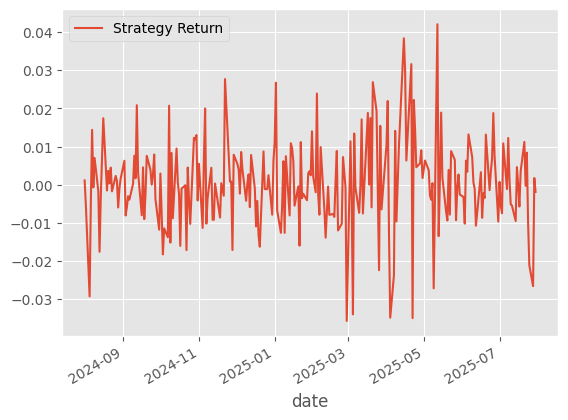

In [428]:
portfolio_df.plot()

# Visualize portfolio returns as compared to NIFTY 50 INDEX

In [429]:
nifty = yf.download(tickers='NIFTYBEES.NS',
                    start='2015-01-01',
                    end=dt.date.today())

nifty_ret = np.log(nifty[['Close']]).diff().dropna().rename({'Close': 'NIFTY 50 Buy&Hold'}, axis=1)

# ✅ Flatten MultiIndex columns if they exist (CRITICAL STEP)
if isinstance(nifty_ret.columns, pd.MultiIndex):
    nifty_ret.columns = nifty_ret.columns.get_level_values(0)
portfolio_df = portfolio_df.merge(nifty_ret,
                                  left_index=True,
                                  right_index=True)

portfolio_df


[*********************100%***********************]  1 of 1 completed


,Strategy Return,NIFTY 50 Buy&Hold
2024-08-01,0.001096,0.002086
2024-08-02,-0.005578,-0.009530
2024-08-05,-0.029323,-0.022783
2024-08-06,-0.004351,-0.006964
2024-08-07,0.014366,0.012957
...,...,...
2025-07-24,-0.010100,-0.005056
2025-07-25,-0.021183,-0.007365
2025-07-28,-0.026631,-0.005515
2025-07-29,0.001737,0.005729


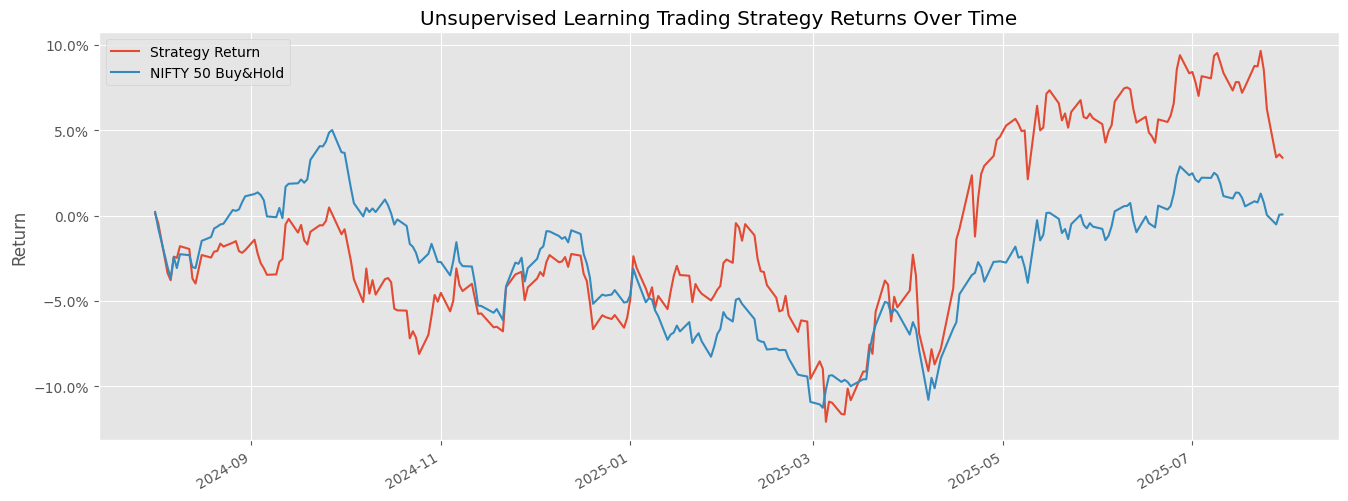

In [430]:
import matplotlib.ticker as mtick

plt.style.use('ggplot')

portfolio_cumulative_return = np.exp(np.log1p(portfolio_df).cumsum())-1

portfolio_cumulative_return[:'2025-07-30'].plot(figsize=(16,6))

plt.title('Unsupervised Learning Trading Strategy Returns Over Time')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.ylabel('Return')

plt.show()